<table>
<tr>    
<td style="text-align: center">
<h1>Transformer Neworks and Text Classification with BERT</h1>
<h2><a href="http://home.agh.edu.pl/~horzyk/index.php">Adrian Horzyk</a></h2>
</td> 
<td>
<img src="http://home.agh.edu.pl/~horzyk/im/AdrianHorzyk49BT140h.png" alt="Adrian Horzyk, Professor" title="Adrian Horzyk, Professor" />        
</td> 
</tr>
</table>
<h3><i>Welcome to the interactive lecture and exercises where you can check everything by yourself and experiment!</i></h3>

# Transformer Models: BERT, RoBERTa, ViT, and More


Welcome to this hands-on notebook where we will explore popular transformer models, including BERT, RoBERTa, ViT, and others.
In this notebook, you'll learn about transformer architectures and how to use them for various tasks, such as text classification,
image classification, and hyperparameter optimization.

**Learning Objectives:**
1. Understand the transformer architecture and its applications in NLP and CV.
2. Get hands-on experience with popular models like BERT, RoBERTa, and ViT.
3. Apply these models to tasks like text classification, image classification, and optimization.


## 1. Introduction to Transformers


Transformers are a type of neural network architecture designed to handle sequential data and are especially effective in
Natural Language Processing (NLP) and, more recently, in Computer Vision (CV).

**Key Concepts:**
- Self-Attention: Core mechanism that allows the model to weigh the importance of different parts of the input.
- Positional Encoding: Adds information about the position of words in sequences since transformers process sequences in parallel.


## 2. Popular Transformer Models
!pip install datasets
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'


Here, we briefly introduce several popular transformer models.

- **Text Transformers**: BERT, RoBERTa, T5 are common in NLP tasks.
- **Vision Transformers**: Vision Transformer (ViT) has brought transformers to image classification.
- **Multimodal Transformers**: CLIP, DALL-E use both vision and text data for rich multimodal tasks.


## 3. Introduction to BERT (Bidirectional Encoder Representations from Transformers)

BERT is a transformer model designed for natural language understanding (NLU) tasks, like text classification and question answering.
The model uses a bidirectional approach, meaning it processes text in both directions (left-to-right and right-to-left) to understand
context more effectively.

In this section, we'll fine-tune BERT on a text classification task. BERT is pre-trained on large text datasets and requires only
fine-tuning on specific tasks, making it versatile for NLP applications.

## 4. Setting Up the Environment

In [1]:
# Install necessary libraries
#!pip install transformers torch optuna
!pip install --upgrade transformers evaluate

Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-4.51.3-py3-none-any.whl (10.4 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.48.3
    Uninstalling transformers-4.48.3:
      Successfully uninstalled transformers-4.48.3
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
adapters 1.1.1 requires transformers~=4.48.3, but you have transformers 4.51.3 which is incompatible.


In [2]:
import transformers
import torch
import optuna
print("Libraries installed and imported!")

Libraries installed and imported!


## 5. Working with Text Transformers

### Exercise 1: Text Classification with BERT

In [3]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset

# Load dataset
dataset = load_dataset("imdb")

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")

# Tokenize data
def tokenize_data(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

tokenized_dataset = dataset.map(tokenize_data, batched=True)

# Example code for fine-tuning
training_args = TrainingArguments(
    output_dir='./results', 
    learning_rate=2e-5, 
    per_device_train_batch_size=8, 
    num_train_epochs=10,
    weight_decay=0.01
)
trainer = Trainer(
    model=model, 
    args=training_args, 
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test']
)

2025-04-26 18:55:35.460944: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-26 18:55:36.189558: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
# Start training
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: adrianhorzyk (adrianhorzyk-agh-university-of-krakow) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.365200
1000,0.302300
1500,0.291800
2000,0.283000
2500,0.263100
3000,0.270700
3500,0.188600
4000,0.182400
4500,0.152200
5000,0.175600


IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



TrainOutput(global_step=31250, training_loss=0.07039811176753044, metrics={'train_runtime': 7665.0548, 'train_samples_per_second': 32.616, 'train_steps_per_second': 4.077, 'total_flos': 6.577776384e+16, 'train_loss': 0.07039811176753044, 'epoch': 10.0})

In [5]:
# Step 1: Install and import required libraries
!pip install transformers datasets torch

import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report

print("Libraries installed and imported!")

# Step 2: Load the IMDb dataset
dataset = load_dataset("imdb")

# Step 3: Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Step 4: Tokenize the dataset
def tokenize_data(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=512)

tokenized_dataset = dataset.map(tokenize_data, batched=True)

# Step 5: Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    eval_strategy="epoch",
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=500,
)

# Step 6: Define compute metrics function
def compute_metrics(pred):
    logits, labels = pred
    preds = torch.argmax(torch.tensor(logits), axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# Step 7: Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'].shuffle(seed=42).select(range(4000)),  # Using subset for faster training
    eval_dataset=tokenized_dataset['test'].select(range(1000)),
    compute_metrics=compute_metrics
)

# Step 8: Train the model
trainer.train()

# Step 9: Evaluate the model
results = trainer.evaluate()
print("\nEvaluation results:", results)

# Step 10: Make predictions on some test samples
predictions = trainer.predict(tokenized_dataset['test'].select(range(10)))
predicted_labels = torch.argmax(torch.tensor(predictions.predictions), axis=1)

# Step 11: Show example predictions
id2label = {0: "Negative", 1: "Positive"}

for idx, example in enumerate(dataset['test'].select(range(10))):
    print(f"\nExample {idx+1}:")
    print("Review:", example['text'][:500], "...")  # Truncate long reviews
    print("True label:", id2label[example['label']])
    print("Predicted label:", id2label[predicted_labels[idx].item()])


Defaulting to user installation because normal site-packages is not writeable
Libraries installed and imported!


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.400100,0.855576,0.721000
2,0.204200,0.400600,0.897000
3,0.084600,0.517386,0.897000
4,0.046500,0.336737,0.938000
5,0.028600,0.930178,0.867000
6,0.022600,0.967986,0.873000
7,0.010500,0.732388,0.901000
8,0.008500,0.760714,0.904000
9,0.005600,0.634523,0.921000
10,0.003000,0.867585,0.891000



Evaluation results: {'eval_loss': 0.8675851225852966, 'eval_accuracy': 0.891, 'eval_runtime': 9.898, 'eval_samples_per_second': 101.031, 'eval_steps_per_second': 12.629, 'epoch': 10.0}

Example 1:
Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi  ...
True label: Negative
Predicted label: Negative

Example 2:
Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even

### Transformer for the IMDB dataset

In [6]:
# Step 1: Import Libraries
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import pipeline
from datasets import load_dataset
import numpy as np
import optuna
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
# Step 2: Load IMDb Dataset
# This dataset contains movie reviews labeled as positive or negative for sentiment analysis
print("Loading dataset...")
dataset = load_dataset("imdb")

Loading dataset...


In [8]:
# Step 3: Load Tokenizer and Model
# We use 'bert-base-uncased', a BERT model pretrained with 12 layers and 110M parameters
print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased")

Loading tokenizer and model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# Step 4: Tokenize the Dataset
# Tokenization converts the text data to token IDs that BERT can process
def tokenize_data(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

print("Tokenizing dataset...")
tokenized_dataset = dataset.map(tokenize_data, batched=True)

Tokenizing dataset...


In [10]:
# Step 5: Define Evaluation Metrics
# We will use accuracy, precision, recall, and F1-score as evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [11]:
# Step 6: Define Training Arguments
# Here we set essential training parameters
training_args = TrainingArguments(
    output_dir='./results',             # Directory to save model checkpoints
    learning_rate=2e-5,                 # Controls how quickly the model updates weights
    per_device_train_batch_size=8,      # Number of samples processed before updating model
    num_train_epochs=10,                 # Number of full passes through the dataset
    weight_decay=0.01,                  # Regularization term to avoid overfitting
    eval_strategy="epoch",        # Evaluate the model at the end of each epoch
    save_strategy="epoch",              # Set save_strategy to match evaluation_strategy
    logging_dir='./logs',               # Directory to save logs for tracking metrics
    load_best_model_at_end=True         # Load the best model based on validation performance
)

In [12]:
# Step 7: Initialize Trainer
# Trainer simplifies the training and evaluation process, allowing us to focus on experimentation
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

In [13]:
# Step 8: Train the Model
print("Training the model...")
trainer.train()

Training the model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.275700,0.373490,0.894320,0.969518,0.814240,0.885120
2,0.178200,0.298164,0.926920,0.960400,0.890560,0.924163
3,0.117800,0.354211,0.935120,0.932216,0.938480,0.935337
4,0.068100,0.337455,0.936560,0.944526,0.927600,0.935986
5,0.036700,0.451796,0.937040,0.925070,0.951120,0.937914
6,0.020100,0.483865,0.934360,0.914687,0.958080,0.935881
7,0.000200,0.537126,0.932840,0.912103,0.958000,0.934488
8,0.011300,0.499306,0.938840,0.938454,0.939280,0.938867
9,0.002600,0.512944,0.939840,0.940615,0.938960,0.939787
10,0.001400,0.517268,0.940160,0.940160,0.940160,0.940160


IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



TrainOutput(global_step=31250, training_loss=0.07330159867662192, metrics={'train_runtime': 8468.1952, 'train_samples_per_second': 29.522, 'train_steps_per_second': 3.69, 'total_flos': 6.577776384e+16, 'train_loss': 0.07330159867662192, 'epoch': 10.0})

In [14]:
# Step 9: Evaluate Model Performance
print("Evaluating model performance on the test set...")
eval_results = trainer.evaluate()

Evaluating model performance on the test set...


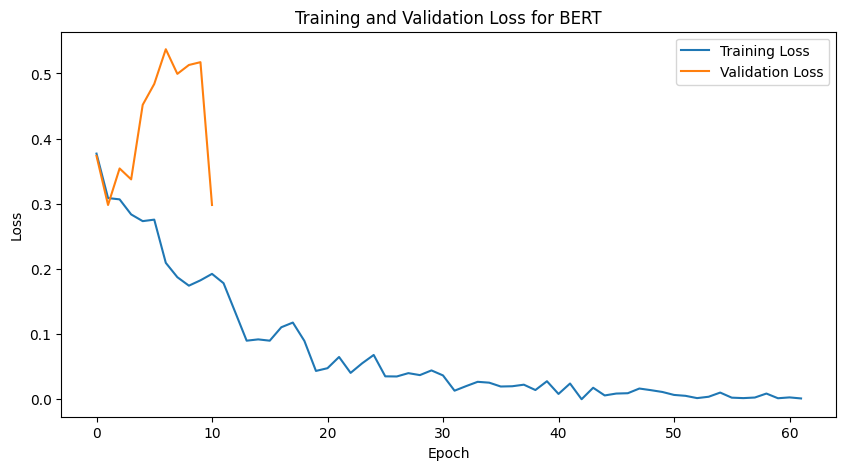

In [15]:
# Step 10: Plot Training and Validation Loss
# Here we plot the training and validation loss to observe the model's learning behavior
metrics = trainer.state.log_history
train_loss = [x["loss"] for x in metrics if "loss" in x]
eval_loss = [x["eval_loss"] for x in metrics if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for BERT")
plt.legend()
plt.show()

In [16]:
# Step 11: Display Evaluation Metrics
print("Evaluation Results:", eval_results)

Evaluation Results: {'eval_loss': 0.2981635332107544, 'eval_accuracy': 0.92692, 'eval_precision': 0.9604003105857993, 'eval_recall': 0.89056, 'eval_f1': 0.9241625503299987, 'eval_runtime': 195.8475, 'eval_samples_per_second': 127.65, 'eval_steps_per_second': 15.956, 'epoch': 10.0}


In [17]:
# Step 12: Detailed Classification Report
# This step provides accuracy, precision, recall, and F1 for each class
predictions = trainer.predict(tokenized_dataset['test'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids
print(classification_report(true_labels, pred_labels, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93     12500
    Positive       0.96      0.89      0.92     12500

    accuracy                           0.93     25000
   macro avg       0.93      0.93      0.93     25000
weighted avg       0.93      0.93      0.93     25000



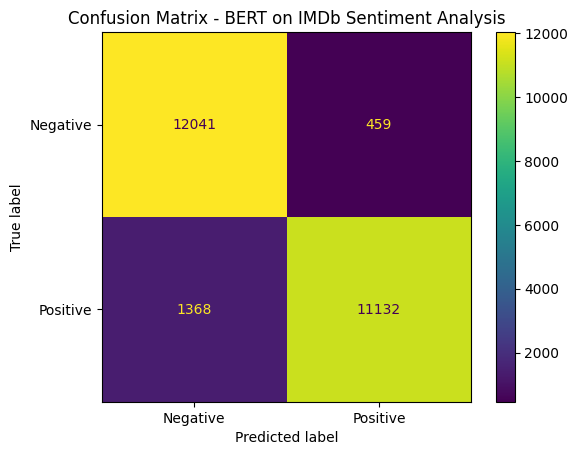

In [18]:
# Step 13: Display Confusion Matrix
# A confusion matrix visualizes the model's predictions against the actual labels
ConfusionMatrixDisplay.from_predictions(true_labels, pred_labels, display_labels=["Negative", "Positive"])
plt.title("Confusion Matrix - BERT on IMDb Sentiment Analysis")
plt.show()

## Optional Experimentation Blocks and Exercises

### Exercise 1: Experiment with Different Learning Rates

Objective: Observe how changing the learning rate affects training stability and model performance.

In [19]:
# Example of experimenting with a higher learning rate
training_args_experiment = TrainingArguments(
    output_dir='./results_experiment',
    learning_rate=5e-5,  # Higher learning rate for experimentation
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs_experiment',
    load_best_model_at_end=True
)

trainer_experiment = Trainer(
    model=model, 
    args=training_args_experiment,
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

# Uncomment below to train with modified learning rate
trainer_experiment.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.151000,0.356364,0.921760,0.951757,0.888560,0.919073
2,0.078600,0.335801,0.932160,0.948969,0.913440,0.930866
3,0.032000,0.401833,0.939320,0.946064,0.931760,0.938858


TrainOutput(global_step=9375, training_loss=0.10198153717041016, metrics={'train_runtime': 2443.5171, 'train_samples_per_second': 30.693, 'train_steps_per_second': 3.837, 'total_flos': 1.9733329152e+16, 'train_loss': 0.10198153717041016, 'epoch': 3.0})

### Exercise 2: Hyperparameter Optimization with Optuna

Objective: Use Optuna to optimize hyperparameters and find the best configuration for learning_rate, batch_size, and num_epochs.

In [20]:
def model_objective(trial):
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    num_epochs = trial.suggest_int("num_epochs", 2, 5)
    
    training_args_opt = TrainingArguments(
        output_dir='./results_optuna',
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_dir='./logs_optuna'
    )
    
    trainer_opt = Trainer(
        model=model, 
        args=training_args_opt,
        train_dataset=tokenized_dataset['train'], 
        eval_dataset=tokenized_dataset['test'],
        compute_metrics=compute_metrics
    )
    
    trainer_opt.train()
    eval_results = trainer_opt.evaluate()
    return eval_results["eval_accuracy"]

# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(model_objective, n_trials=5)

print("Best Hyperparameters:", study.best_params)


[I 2025-04-27 00:35:00,377] A new study created in memory with name: no-name-b939ce73-0372-4c14-ae16-f42dcbaeea88
/tmp/ipykernel_907768/3171795677.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-4)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.032700,0.409684,0.932520,0.910672,0.959120,0.934268
2,0.014700,0.430662,0.936880,0.935764,0.938160,0.936961
3,0.006700,0.459405,0.937800,0.930939,0.945760,0.938291


[I 2025-04-27 01:15:53,222] Trial 0 finished with value: 0.93252 and parameters: {'learning_rate': 1.930710075020043e-05, 'batch_size': 16, 'num_epochs': 3}. Best is trial 0 with value: 0.93252.
/tmp/ipykernel_907768/3171795677.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-4)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.031800,0.383782,0.933200,0.938746,0.926880,0.932775
2,0.014600,0.397017,0.937280,0.939460,0.934800,0.937124
3,0.009400,0.427610,0.937960,0.931165,0.945840,0.938445
4,0.002000,0.447013,0.937200,0.940939,0.932960,0.936933


[I 2025-04-27 02:07:13,394] Trial 1 finished with value: 0.9332 and parameters: {'learning_rate': 3.566593406978598e-05, 'batch_size': 32, 'num_epochs': 4}. Best is trial 1 with value: 0.9332.
/tmp/ipykernel_907768/3171795677.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-4)


Epoch,Training Loss,Validation Loss


### Exercise 3: Add a Text Classification Pipeline for Inference

Objective: Create an inference pipeline to classify new text samples after training.

In [21]:
# Load the fine-tuned model and tokenizer in a pipeline for inference
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# Sample inference on new reviews
print(classifier("This movie was fantastic!"))
print(classifier("The plot was terrible and I didn't enjoy it at all."))

## Explanation of Key Steps

Tokenization: Converts raw text into token IDs. Padding ensures sequences in each batch are the same length.
Training: Trainer API simplifies the process with functions for training and evaluation.
Evaluation: Computes metrics, visualizes loss, and displays a confusion matrix to interpret model performance.
Optimization: With Optuna, students can try different combinations of hyperparameters to find the best-performing model.

## Assignments

* Experiment with Different Learning Rates: Adjust the learning rate to see its effect on training convergence.
* Hyperparameter Tuning with Optuna: Use Optuna to automate hyperparameter search and observe the impact of each setting.
* Inference on New Text: Implement a text classification pipeline and test it on custom sentences.
* This setup provides a full workflow for BERT-based text classification, from setup to training, tuning, and evaluation.
* Try train longer with different hyperparameters and compare the achieved results.
* Try to optimize hyperparameters with Optuna and compare the achieved results.
* Add an Inference Pipeline and compare the achieved results.

Send me back the notebook with your solution, presenting your experiments and results in a separate notebook.

## 6. Hyperparameter Optimization with Optuna

In [22]:
import optuna

def objective(trial):
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    # Define training args
    training_args = TrainingArguments(
        output_dir='./results', 
        learning_rate=learning_rate, 
        per_device_train_batch_size=batch_size, 
        num_train_epochs=2,
        weight_decay=0.01
    )
    trainer = Trainer(
        model=model, 
        args=training_args, 
        train_dataset=tokenized_dataset['train'], 
        eval_dataset=tokenized_dataset['test']
    )
    # Training and evaluation go here...
    return evaluation metrics

In [ ]:
# Start Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=5)

## Conclusion


In this notebook, we've explored various transformer models for text and image tasks. By fine-tuning BERT for sentiment analysis,
ViT for image classification, and optimizing hyperparameters with Optuna, you have gained hands-on experience with modern
transformer-based architectures.

**Further Reading**:
- Hugging Face Transformers documentation
- Papers for BERT, ViT, and other transformer models



## Hyperparameter Explanation and Exercises

Transformers have several important hyperparameters that influence training efficiency and model performance.
Here is an explanation of these hyperparameters, typical ranges, and exercises for students to understand
their impact on transformer models.

### Key Hyperparameters

1. **Learning Rate (`learning_rate`)**
   - **Description**: Controls how much the model weights are adjusted during training. A high learning rate
     can lead to rapid updates and possible divergence, while a very low learning rate may slow down convergence.
   - **Typical Range**: `1e-5` to `5e-4`
   - **Student Exercise**: Experiment with learning rates to find a balance between fast convergence and stable
     training. Observe training losses and validation performance as the rate changes.

2. **Batch Size (`batch_size`)**
   - **Description**: Number of samples processed together before updating the model parameters.
   - **Typical Choices**: 8, 16, 32, or 64. Smaller batch sizes can help avoid memory issues on GPUs.
   - **Student Exercise**: Try different batch sizes to see the effect on training stability, speed, and memory usage.

3. **Number of Epochs (`num_epochs`)**
   - **Description**: The number of complete passes through the dataset during training. More epochs allow more training but can lead to overfitting.
   - **Typical Range**: 2 to 10 epochs
   - **Student Exercise**: Monitor validation performance over epochs to observe if the model starts overfitting,
     and determine an optimal epoch count for early stopping.

4. **Weight Decay (`weight_decay`)**
   - **Description**: Adds a regularization penalty on the model weights to avoid overfitting. Higher values encourage
     smaller weights, potentially preventing overfitting.
   - **Typical Range**: 0 to 0.01
   - **Student Exercise**: Adjust weight decay to observe its effect on the generalization of the model and monitor
     validation accuracy.

### Optimization Exercise with Optuna

Using Optuna, students can try different hyperparameters by defining an objective function, such as maximizing validation
accuracy or minimizing loss. By experimenting with these combinations, they can learn the balance of these hyperparameters
to improve model performance.
